# Project M

Final notebook version for modeling intubation risk in the Parkinson + pneumonia cohort.

This version is built to run directly from `my_dataset.csv` without repeating MIMIC extraction. The workflow is:
1. Load the already extracted dataset.
2. Perform structured EDA.
3. Clean implausible values, cap outliers, and treat missingness.
4. Prepare train/dev/test splits.
5. Train and tune the same family of logistic models, then evaluate on a held-out test set.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, spearmanr
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="talk")
RANDOM_STATE = 42
TARGET = "intubation"
DATA_PATH = Path("my_dataset.csv")


## 1. Load The Extracted Dataset

The notebook now uses the saved extraction output directly. No raw MIMIC tables are required for the standard workflow.


In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} was not found. The final workflow expects the pre-extracted CSV in the project folder."
    )

date_cols = ["first_intubation_time", "admittime", "baseline_end", "dischtime"]
df_raw = pd.read_csv(DATA_PATH, parse_dates=[c for c in date_cols if c in pd.read_csv(DATA_PATH, nrows=0).columns])
if "gender" in df_raw.columns:
    df_raw["gender"] = df_raw["gender"].map({"M": 0, "F": 1}).astype("Int64")
print(f"Loaded dataset from {DATA_PATH.resolve()}")
print(f"Rows: {len(df_raw)} | Columns: {df_raw.shape[1]}")
print("Gender coding applied: F=1, M=0")
print("Target balance:")
display(df_raw[TARGET].value_counts(dropna=False).rename_axis(TARGET).to_frame("count"))
display(df_raw.head())


Loaded dataset from /Users/mariaalexeenko/Desktop/hava/my_dataset.csv
Rows: 327 | Columns: 49
Gender coding applied: F=1, M=0
Target balance:


,count
intubation,
0,276
1,51


,hadm_id,subject_id,age,gender,bmi,parkinson_dx,levodopa_use,dopamine_agonist_use,anticholinergic_use,dbs_history,intubation,first_intubation_time,hours_to_intubation,mv_duration_hours,aspiration_pneumonia,pneumonia_any,dysphagia,heart_rate,sbp,temperature_c,resp_rate,spo2,fio2,gcs_total,wbc,crp,albumin,creatinine,lactate,sodium,ph_arterial,pao2,pf_ratio,dementia,diabetes,heart_failure,copd_asthma,malnutrition,uti,hypertension,renal_failure,smoking_icd,charlson_index,icu_admission_baseline,vasopressor_baseline,admittime,baseline_end,dischtime,hospital_expire_flag
0,21370169,10033409,78,1,32.2,1,1,0,0,0,0,NaT,NaN,0.0,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,0,0,1,1,0,5,0,0,2113-06-27 11:53:00,2113-06-27 17:53:00,2113-07-02 18:08:00,0
1,24421300,10048825,72,0,31.2,1,1,0,0,0,0,NaT,NaN,0.0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,0,0,8,0,0,2187-03-24 22:16:00,2187-03-25 04:16:00,2187-03-26 15:43:00,0
2,20050796,10050755,85,0,19.9,1,1,0,0,0,0,NaT,NaN,0.0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,0,1,0,0,4,0,0,2134-02-25 18:41:00,2134-02-26 00:41:00,2134-02-26 01:26:00,1
3,20724333,10050755,85,0,30.7,1,1,0,0,0,0,NaT,NaN,0.0,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,0,1,0,0,4,0,0,2134-02-12 23:51:00,2134-02-13 05:51:00,2134-02-16 14:38:00,0
4,26698047,10050755,85,0,22.5,1,1,0,0,0,0,NaT,NaN,0.0,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.2,NaN,2.7,1.3,NaN,150.0,NaN,NaN,NaN,1,0,0,0,1,0,1,0,0,4,0,0,2134-01-03 22:37:00,2134-01-04 04:37:00,2134-01-29 17:38:00,0


## 2. EDA: General Overview


In [3]:
overview_df = pd.DataFrame(
    {
        "variable": df_raw.columns,
        "dtype": [str(df_raw[c].dtype) for c in df_raw.columns],
        "missing_n": [int(df_raw[c].isna().sum()) for c in df_raw.columns],
        "missing_pct": [round(df_raw[c].isna().mean() * 100, 1) for c in df_raw.columns],
        "n_unique": [int(df_raw[c].nunique(dropna=False)) for c in df_raw.columns],
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, True])

target_summary = pd.DataFrame(
    {
        "class": df_raw[TARGET].value_counts().index,
        "count": df_raw[TARGET].value_counts().values,
        "pct": (df_raw[TARGET].value_counts(normalize=True).values * 100).round(1),
    }
)

display(overview_df)
display(target_summary)


,variable,dtype,missing_n,missing_pct,n_unique
25,crp,float64,320,97.9,8
32,pf_ratio,float64,302,92.4,26
26,albumin,float64,294,89.9,18
30,ph_arterial,float64,278,85.0,25
31,pao2,float64,278,85.0,39
11,first_intubation_time,datetime64[us],276,84.4,52
12,hours_to_intubation,float64,276,84.4,52
22,fio2,float64,275,84.1,10
28,lactate,float64,275,84.1,34
24,wbc,float64,237,72.5,78


,class,count,pct
0,0,276,84.4
1,1,51,15.6


In [4]:
id_cols = ["hadm_id", "subject_id"]
time_cols = ["first_intubation_time", "admittime", "baseline_end", "dischtime"]
downstream_cols = ["mv_duration_hours", "hospital_expire_flag", "hours_to_intubation"]
excluded_from_modeling = [c for c in id_cols + time_cols + downstream_cols if c in df_raw.columns]

candidate_df = df_raw.drop(columns=excluded_from_modeling).copy()

binary_features = []
categorical_features = []
numeric_features = []
for col in candidate_df.columns:
    if col == TARGET:
        continue
    non_missing = candidate_df[col].dropna()
    unique_vals = set(non_missing.unique().tolist())
    if candidate_df[col].dtype == "object":
        categorical_features.append(col)
    elif unique_vals and unique_vals.issubset({0, 1}):
        binary_features.append(col)
        categorical_features.append(col)
    else:
        numeric_features.append(col)

print("Excluded from modeling:", excluded_from_modeling)
print("Categorical/binary features:")
print(categorical_features)
print("\nContinuous numeric features:")
print(numeric_features)
print(
    "\nDecision: not all variables are converted to categorical. "
    "Age, BMI, vitals, and labs are kept numeric because converting them to categories would discard clinical ordering and distance information."
)


Excluded from modeling: ['hadm_id', 'subject_id', 'first_intubation_time', 'admittime', 'baseline_end', 'dischtime', 'mv_duration_hours', 'hospital_expire_flag', 'hours_to_intubation']
Categorical/binary features:
['gender', 'parkinson_dx', 'levodopa_use', 'dopamine_agonist_use', 'anticholinergic_use', 'dbs_history', 'aspiration_pneumonia', 'pneumonia_any', 'dysphagia', 'dementia', 'diabetes', 'heart_failure', 'copd_asthma', 'malnutrition', 'uti', 'hypertension', 'renal_failure', 'smoking_icd', 'icu_admission_baseline', 'vasopressor_baseline']

Continuous numeric features:
['age', 'bmi', 'heart_rate', 'sbp', 'temperature_c', 'resp_rate', 'spo2', 'fio2', 'gcs_total', 'wbc', 'crp', 'albumin', 'creatinine', 'lactate', 'sodium', 'ph_arterial', 'pao2', 'pf_ratio', 'charlson_index']

Decision: not all variables are converted to categorical. Age, BMI, vitals, and labs are kept numeric because converting them to categories would discard clinical ordering and distance information.


## 3. EDA: Distributions And Class Balance


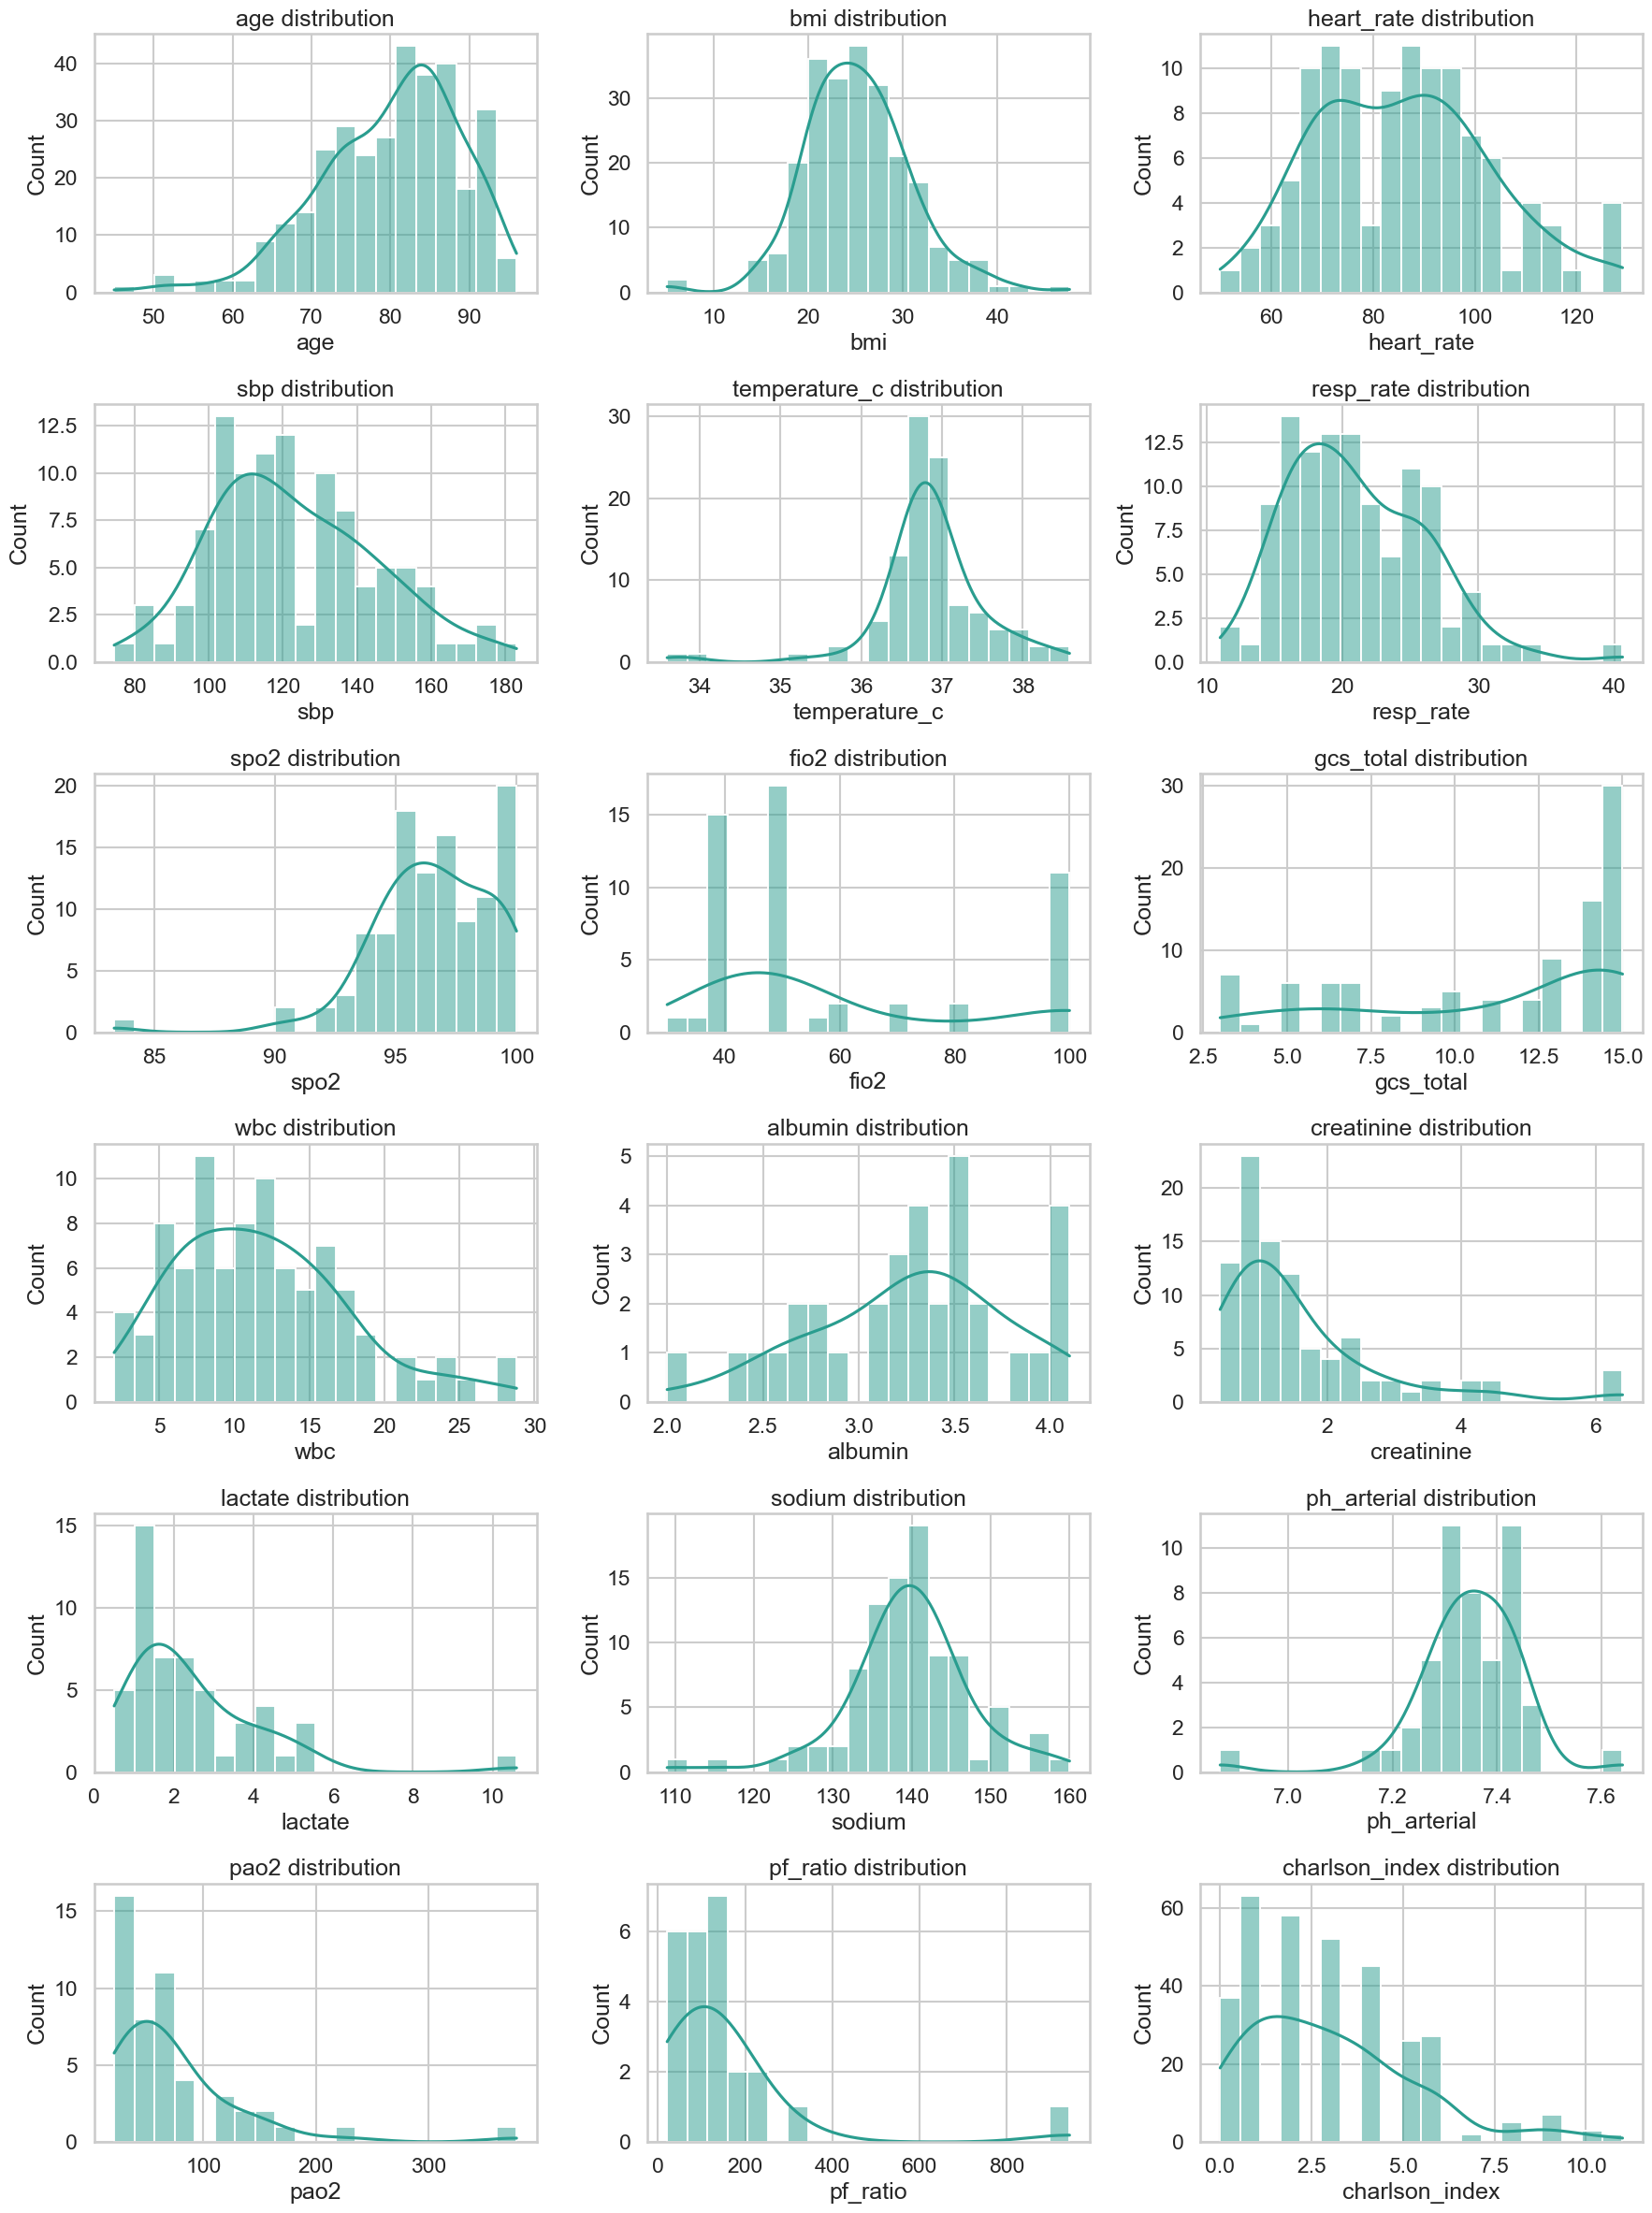

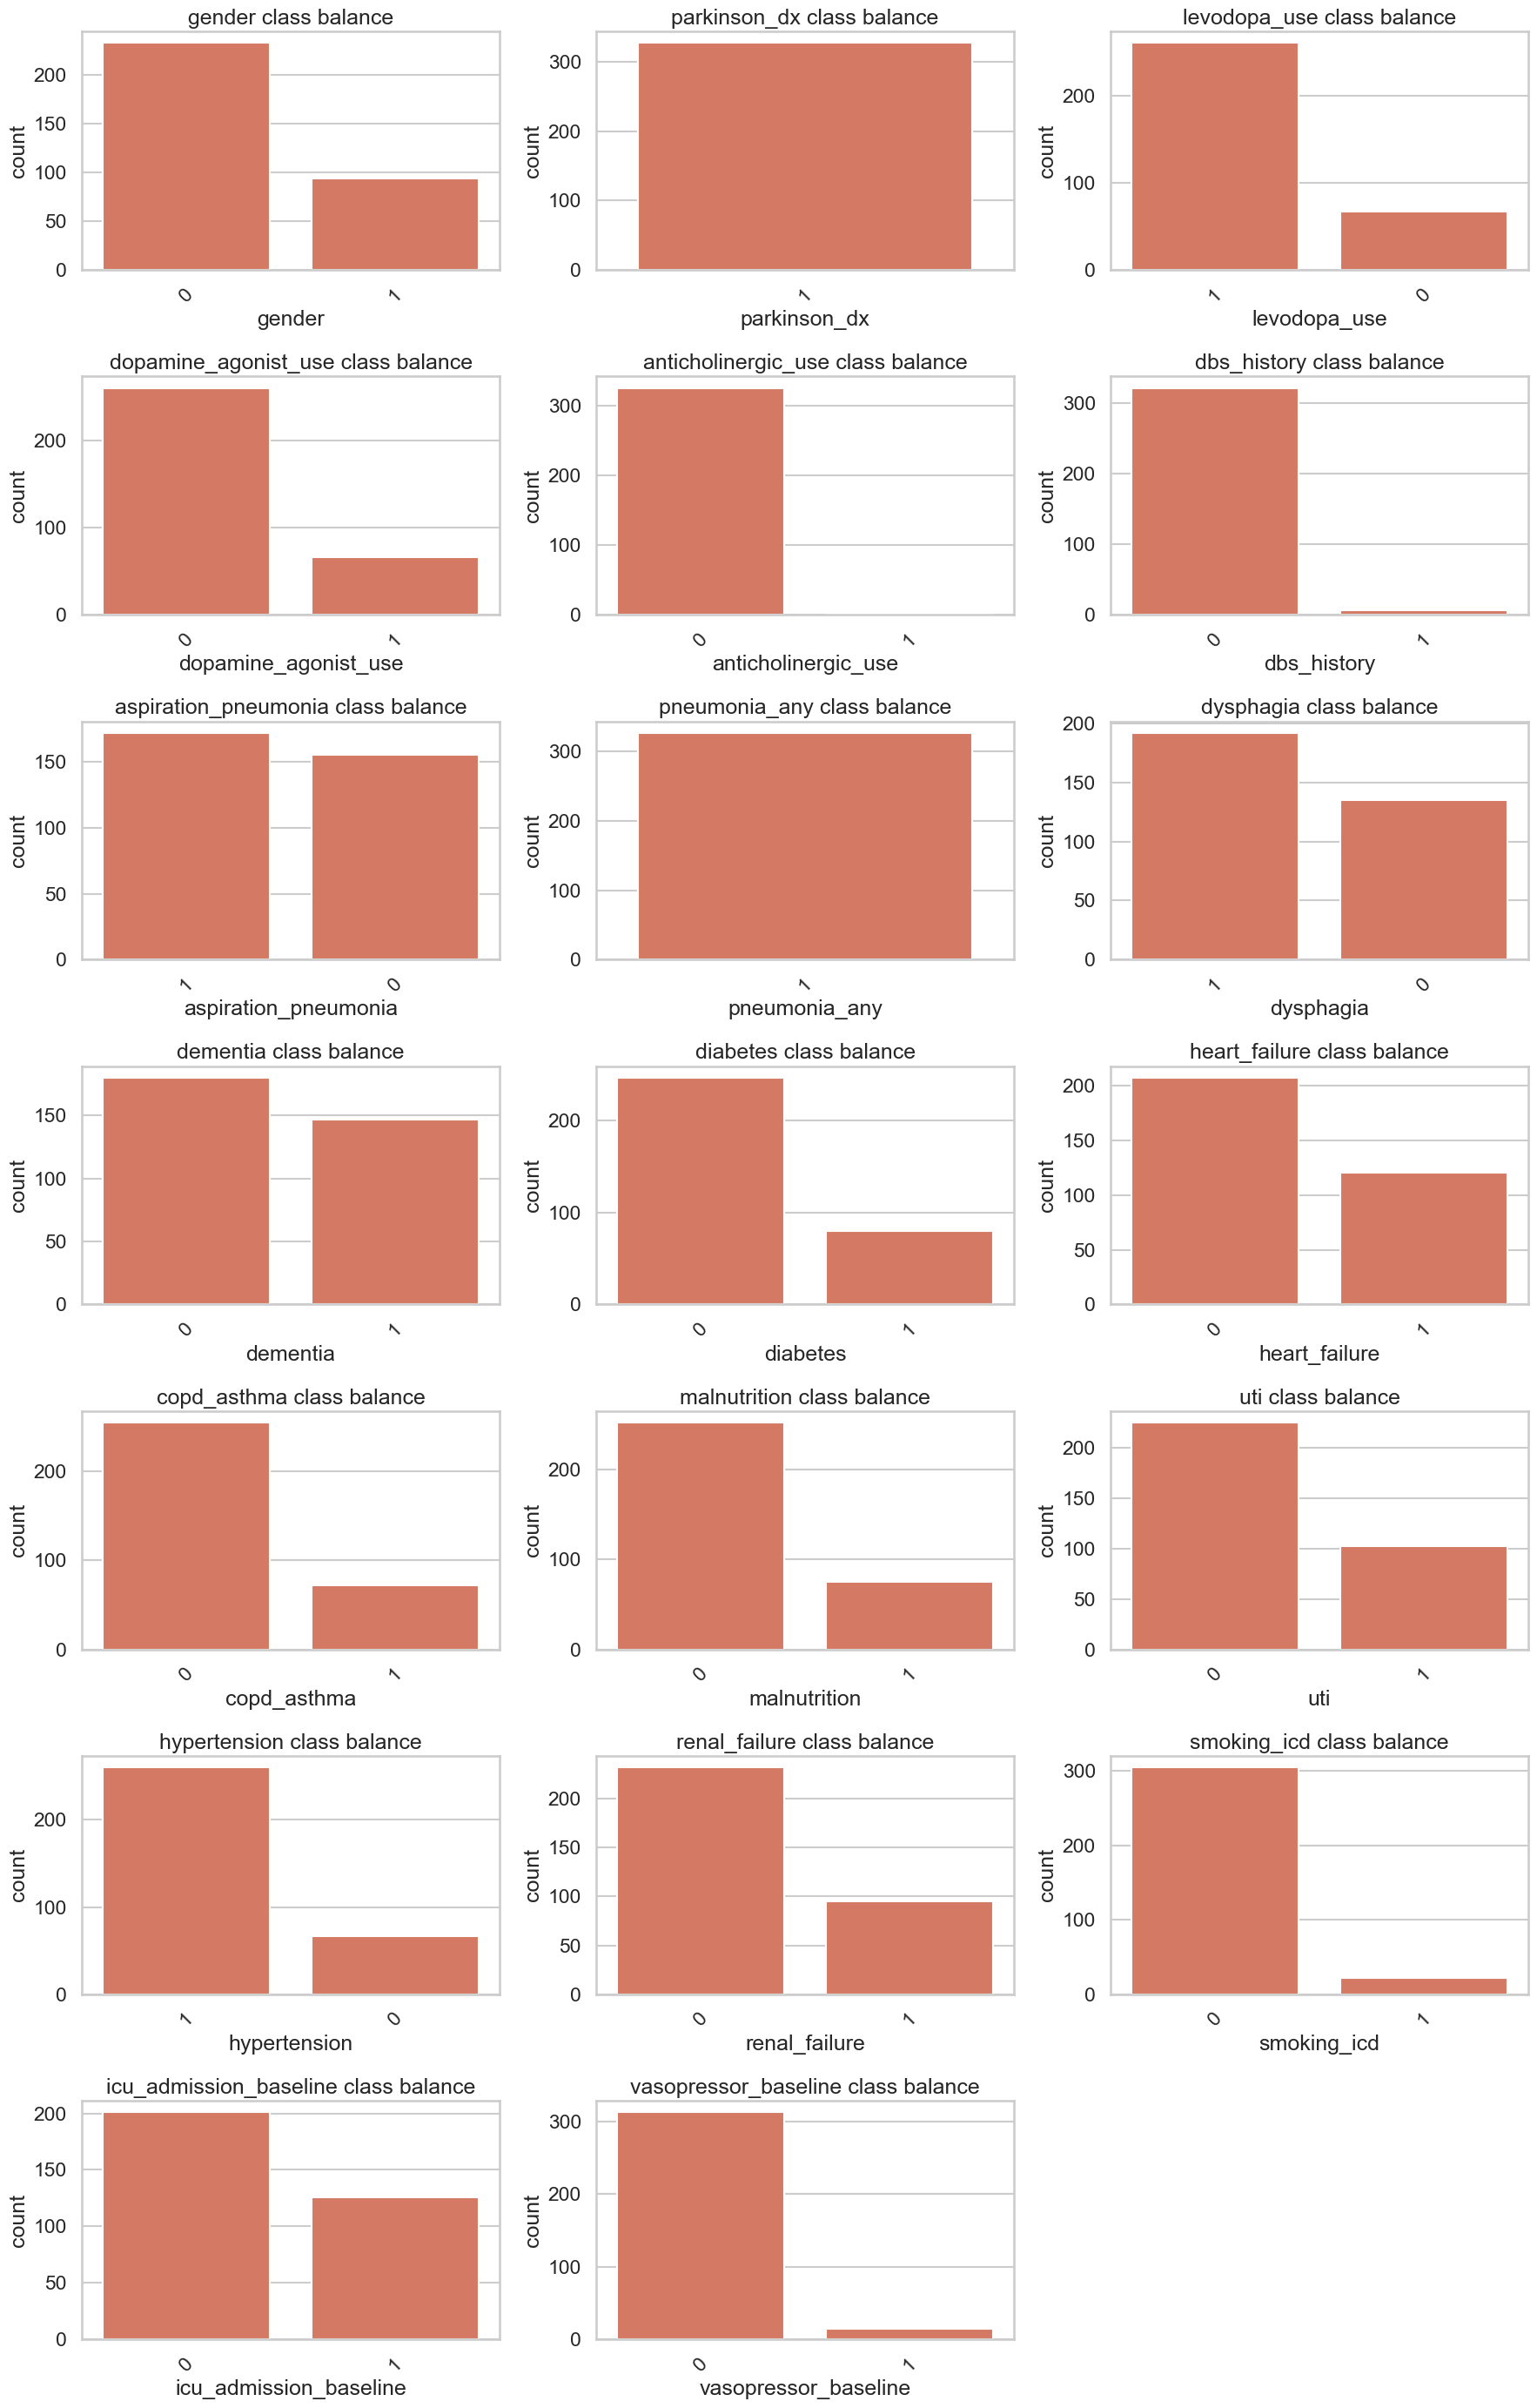

In [5]:
plot_numeric = [c for c in numeric_features if candidate_df[c].notna().sum() >= 25]
n_cols = 3
n_rows = int(np.ceil(len(plot_numeric) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, max(4 * n_rows, 6)))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, plot_numeric):
    sns.histplot(candidate_df[col], kde=True, bins=20, ax=ax, color="#2a9d8f")
    ax.set_title(f"{col} distribution")
for ax in axes[len(plot_numeric):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

plot_categorical = [c for c in categorical_features if candidate_df[c].nunique(dropna=True) <= 10]
n_rows = int(np.ceil(len(plot_categorical) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, max(4 * n_rows, 6)))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, plot_categorical):
    counts = candidate_df[col].fillna("Missing").astype(str).value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, color="#e76f51")
    ax.set_title(f"{col} class balance")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=45)
for ax in axes[len(plot_categorical):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. EDA: Statistical Tests Against The Target


In [6]:
def format_p_value(p):
    if pd.isna(p):
        return np.nan
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

def run_feature_tests(df_in, target):
    rows = []
    for col in df_in.columns:
        if col == target:
            continue
        s = df_in[col]
        if pd.api.types.is_numeric_dtype(s) and s.nunique(dropna=True) > 5:
            group0 = df_in.loc[df_in[target] == 0, col].dropna()
            group1 = df_in.loc[df_in[target] == 1, col].dropna()
            p_value = (
                mannwhitneyu(group0, group1, alternative="two-sided").pvalue
                if len(group0) and len(group1)
                else np.nan
            )
            effect = spearmanr(df_in[col], df_in[target], nan_policy="omit").statistic
            rows.append(
                {
                    "feature": col,
                    "feature_type": "numeric",
                    "missing_pct": round(s.isna().mean() * 100, 1),
                    "effect_size": round(float(effect), 3) if pd.notna(effect) else np.nan,
                    "test": "Mann-Whitney U + Spearman",
                    "p_value": p_value,
                }
            )
        else:
            tab = pd.crosstab(s.fillna("Missing"), df_in[target])
            if tab.shape == (2, 2):
                test_name = "Fisher exact"
                p_value = fisher_exact(tab)[1]
            else:
                test_name = "Chi-square"
                p_value = chi2_contingency(tab)[1] if tab.shape[1] == 2 and tab.shape[0] >= 2 else np.nan
            rows.append(
                {
                    "feature": col,
                    "feature_type": "categorical",
                    "missing_pct": round(s.isna().mean() * 100, 1),
                    "effect_size": np.nan,
                    "test": test_name,
                    "p_value": p_value,
                }
            )
    out = pd.DataFrame(rows).sort_values(["p_value", "missing_pct"], na_position="last")
    out["p_value_raw"] = out["p_value"]
    out["p_value"] = out["p_value"].apply(format_p_value)
    return out

feature_test_table = run_feature_tests(candidate_df, TARGET)
display(feature_test_table)


,feature,feature_type,missing_pct,effect_size,test,p_value,p_value_raw
37,icu_admission_baseline,categorical,0.0,NaN,Fisher exact,<0.001,5.775569e-07
17,gcs_total,numeric,69.7,-0.241,Mann-Whitney U + Spearman,0.017,1.717004e-02
36,charlson_index,numeric,0.0,0.123,Mann-Whitney U + Spearman,0.026,2.645962e-02
33,hypertension,categorical,0.0,NaN,Fisher exact,0.039,3.900147e-02
18,wbc,numeric,72.5,0.215,Mann-Whitney U + Spearman,0.043,4.334340e-02
38,vasopressor_baseline,categorical,0.0,NaN,Fisher exact,0.050,5.013430e-02
29,heart_failure,categorical,0.0,NaN,Fisher exact,0.058,5.753120e-02
10,dysphagia,categorical,0.0,NaN,Fisher exact,0.065,6.485180e-02
28,diabetes,categorical,0.0,NaN,Fisher exact,0.075,7.468979e-02
5,dopamine_agonist_use,categorical,0.0,NaN,Fisher exact,0.087,8.732460e-02


## 5. EDA: Correlation Structure


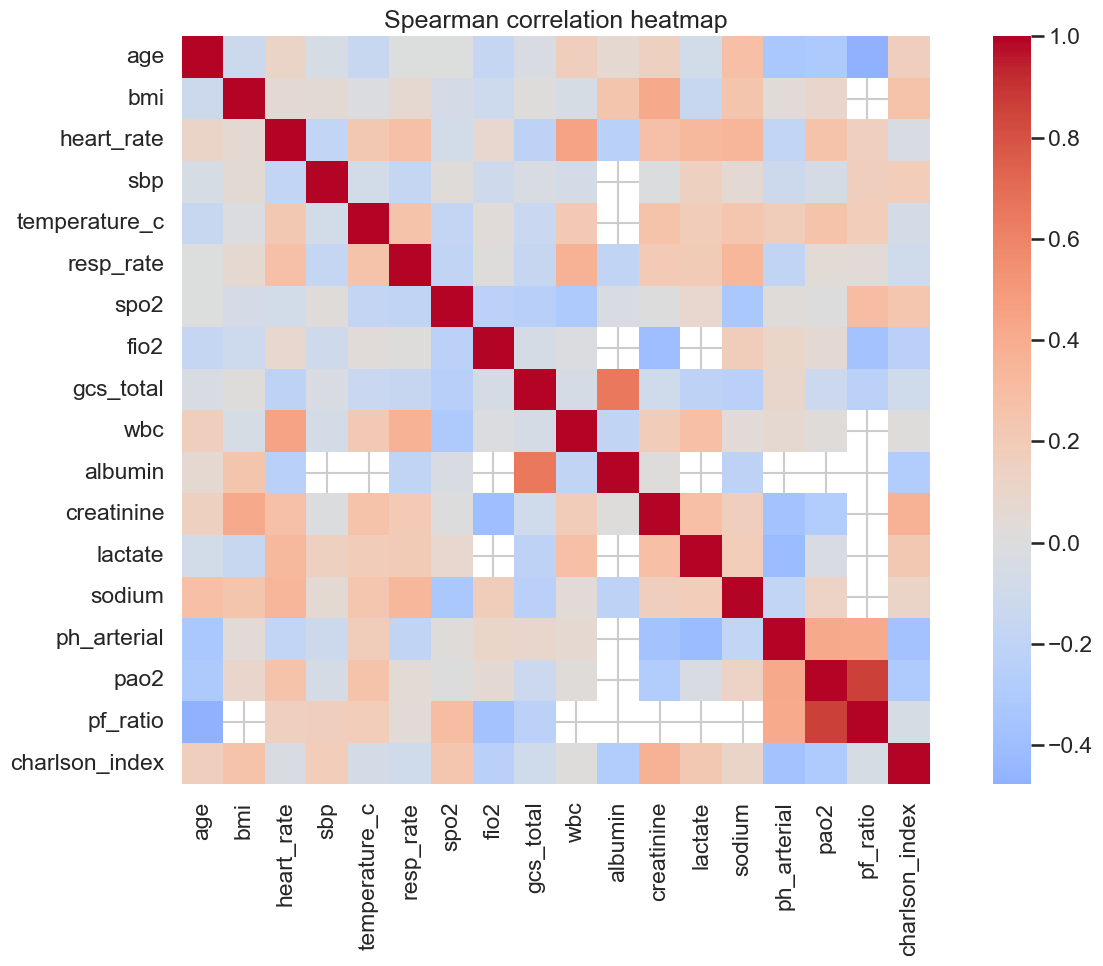

,feature_a,feature_b,n_complete,spearman_r,p_value,p_value_raw
137,pao2,pf_ratio,25,0.865,<0.001,2.332973e-08
104,gcs_total,albumin,20,0.648,0.002,1.999748e-03
15,age,pf_ratio,25,-0.478,0.016,1.576082e-02
38,heart_rate,wbc,53,0.447,<0.001,7.858341e-04
134,ph_arterial,pao2,49,0.418,0.003,2.790615e-03
26,bmi,creatinine,59,0.416,0.001,1.058809e-03
128,lactate,ph_arterial,35,-0.415,0.013,1.307809e-02
135,ph_arterial,pf_ratio,25,0.407,0.044,4.362306e-02
97,fio2,creatinine,21,-0.401,0.071,7.138606e-02
126,creatinine,charlson_index,92,0.374,<0.001,2.360132e-04


Important note: some extreme pairwise correlations are based on very small complete-case overlap because several labs are highly missing. Those relationships should not be treated as stable without checking n_complete.


In [7]:
corr_numeric = [
    c
    for c in candidate_df.columns
    if c != TARGET and pd.api.types.is_numeric_dtype(candidate_df[c]) and candidate_df[c].nunique(dropna=True) > 5 and candidate_df[c].notna().sum() >= 25
]
corr_matrix = candidate_df[corr_numeric].corr(method="spearman", min_periods=20)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Spearman correlation heatmap")
plt.tight_layout()
plt.show()

corr_rows = []
for i, col_a in enumerate(corr_numeric):
    for col_b in corr_numeric[i + 1:]:
        pair = candidate_df[[col_a, col_b]].dropna()
        if len(pair) < 20:
            continue
        rho, p_value = spearmanr(pair[col_a], pair[col_b])
        corr_rows.append(
            {
                "feature_a": col_a,
                "feature_b": col_b,
                "n_complete": len(pair),
                "spearman_r": round(float(rho), 3),
                "p_value": p_value,
            }
        )

corr_table = pd.DataFrame(corr_rows).sort_values("spearman_r", key=lambda s: s.abs(), ascending=False)
corr_table["p_value_raw"] = corr_table["p_value"]
corr_table["p_value"] = corr_table["p_value"].apply(format_p_value)
display(corr_table.head(20))
print(
    "Important note: some extreme pairwise correlations are based on very small complete-case overlap because several labs are highly missing. "
    "Those relationships should not be treated as stable without checking n_complete."
)


## 6. EDA: Outliers And Missingness


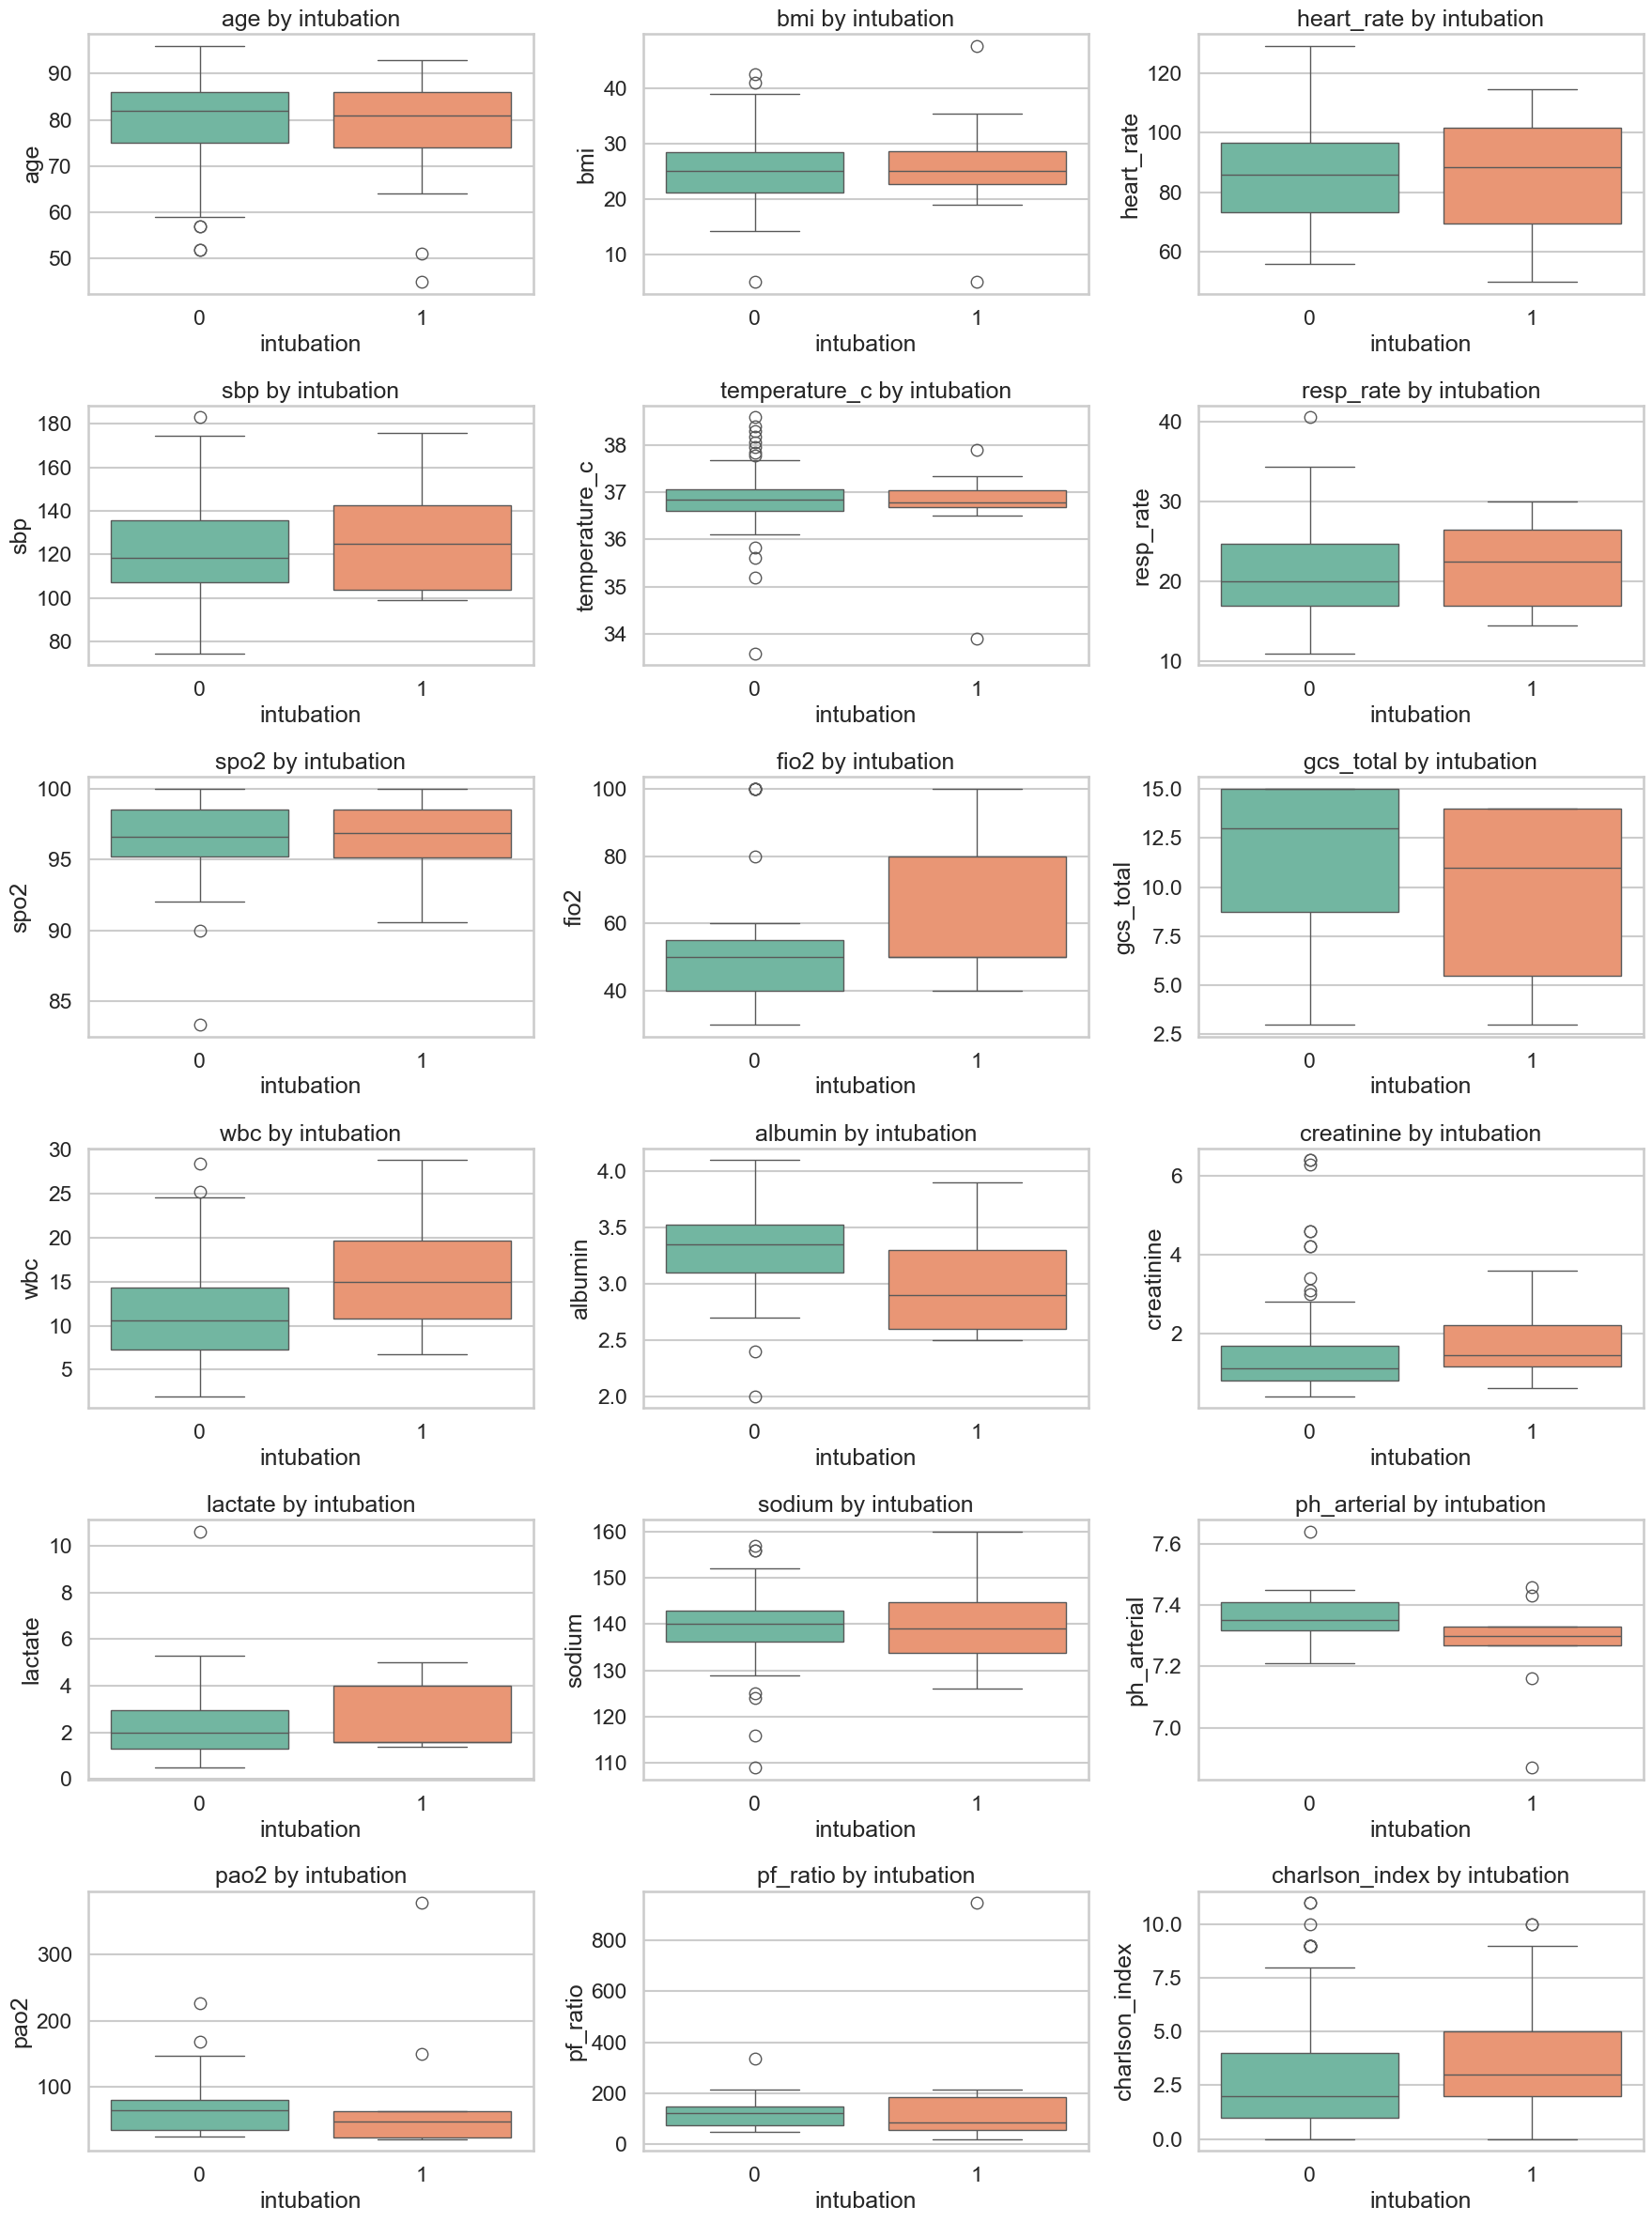

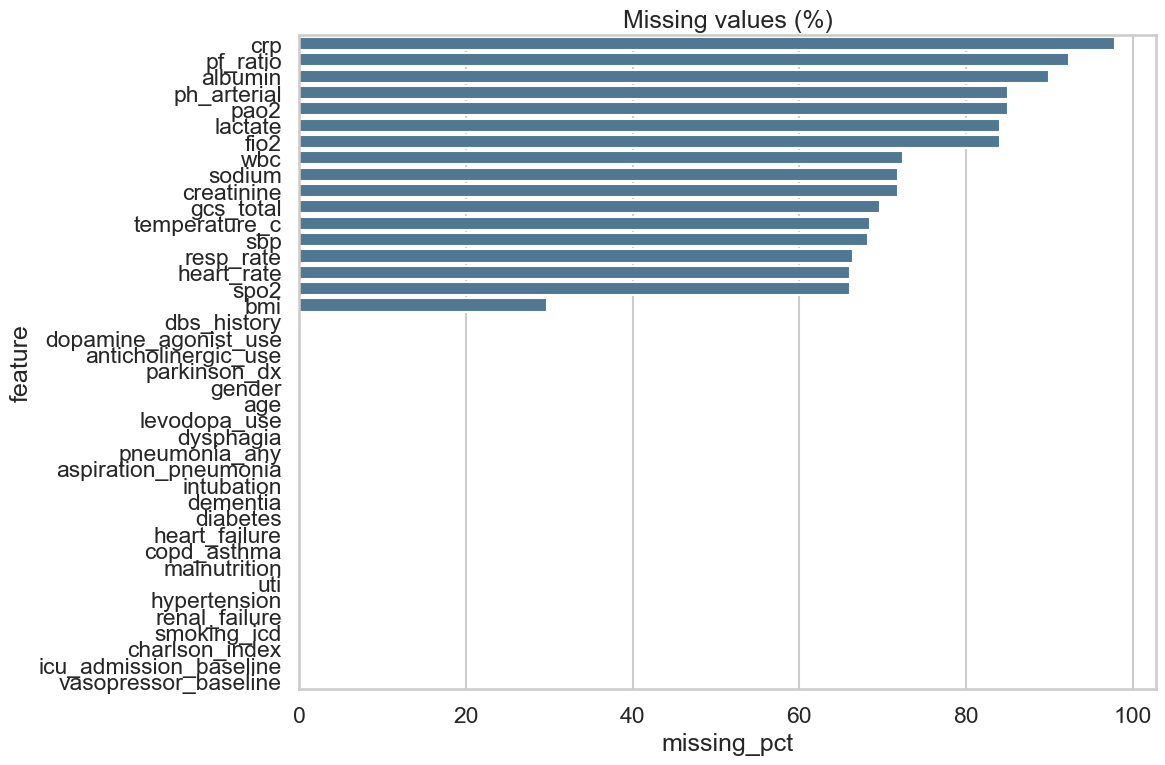

,feature,missing_pct
0,crp,97.9
1,pf_ratio,92.4
2,albumin,89.9
3,ph_arterial,85.0
4,pao2,85.0
5,lactate,84.1
6,fio2,84.1
7,wbc,72.5
8,sodium,71.9
9,creatinine,71.9


In [8]:
boxplot_numeric = [
    c
    for c in candidate_df.columns
    if c != TARGET and pd.api.types.is_numeric_dtype(candidate_df[c]) and candidate_df[c].nunique(dropna=True) > 5 and candidate_df[c].notna().sum() >= 25
]
n_cols = 3
n_rows = int(np.ceil(len(boxplot_numeric) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, max(4 * n_rows, 6)))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, boxplot_numeric):
    sns.boxplot(data=candidate_df, x=TARGET, y=col, ax=ax, palette="Set2")
    ax.set_title(f"{col} by {TARGET}")
for ax in axes[len(boxplot_numeric):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

missing_table = (
    candidate_df.isna()
    .mean()
    .mul(100)
    .round(1)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "feature"})
)
plt.figure(figsize=(12, 8))
sns.barplot(data=missing_table, x="missing_pct", y="feature", color="#457b9d")
plt.title("Missing values (%)")
plt.tight_layout()
plt.show()

display(missing_table)


## 7. Data Treatment: Impossible Values, Outliers, Missingness


In [9]:
physiologic_bounds = {
    "age": (18, 110),
    "bmi": (10, 80),
    "heart_rate": (20, 250),
    "sbp": (40, 300),
    "temperature_c": (30, 43),
    "resp_rate": (4, 80),
    "spo2": (40, 100),
    "fio2": (21, 100),
    "gcs_total": (3, 15),
    "wbc": (0.1, 200),
    "crp": (0, 500),
    "albumin": (0.5, 6),
    "creatinine": (0.1, 20),
    "lactate": (0.1, 30),
    "sodium": (100, 180),
    "ph_arterial": (6.8, 7.8),
    "pao2": (20, 600),
    "pf_ratio": (20, 700),
}

important_high_missing_features = [
    "heart_rate",
    "sbp",
    "temperature_c",
    "resp_rate",
    "spo2",
    "fio2",
    "gcs_total",
    "wbc",
    "creatinine",
    "lactate",
    "sodium",
]

hard_drop_missing_threshold = 85.0
missing_rates = candidate_df.isna().mean().mul(100)
high_missing_drop = [
    col
    for col in candidate_df.columns
    if col != TARGET
    and missing_rates.get(col, 0) > hard_drop_missing_threshold
    and col not in important_high_missing_features
]

df_clean = candidate_df.drop(columns=high_missing_drop).copy()

impossible_mask = pd.Series(False, index=df_clean.index)
impossible_rows_by_feature = {}
for col, (low, high) in physiologic_bounds.items():
    if col not in df_clean.columns:
        continue
    mask = df_clean[col].notna() & ((df_clean[col] < low) | (df_clean[col] > high))
    impossible_rows_by_feature[col] = int(mask.sum())
    impossible_mask = impossible_mask | mask

removed_rows = int(impossible_mask.sum())
df_clean = df_clean.loc[~impossible_mask].copy()

iqr_clip_rows = []
continuous_to_clip = [
    c
    for c in df_clean.columns
    if c != TARGET and pd.api.types.is_numeric_dtype(df_clean[c]) and df_clean[c].nunique(dropna=True) > 5
]
for col in continuous_to_clip:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        continue
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before = df_clean[col].copy()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    iqr_clip_rows.append(
        {
            "feature": col,
            "lower_clip": round(float(lower), 3),
            "upper_clip": round(float(upper), 3),
            "n_clipped": int((before != df_clean[col]).sum(skipna=True)),
        }
    )

treatment_summary = pd.DataFrame(
    {
        "step": [
            "Dropped high-missing features",
            "Removed rows with physiologically impossible values",
            "Applied IQR capping to continuous variables",
        ],
        "details": [
            ", ".join(high_missing_drop) if high_missing_drop else "None",
            removed_rows,
            len(iqr_clip_rows),
        ],
    }
)

display(treatment_summary)
display(pd.DataFrame.from_dict(impossible_rows_by_feature, orient="index", columns=["n_impossible"]).sort_values("n_impossible", ascending=False))
display(pd.DataFrame(iqr_clip_rows).sort_values("n_clipped", ascending=False))


,step,details
0,Dropped high-missing features,"crp, albumin, ph_arterial, pao2, pf_ratio"
1,Removed rows with physiologically impossible v...,2
2,Applied IQR capping to continuous variables,14


,n_impossible
bmi,2
age,0
heart_rate,0
sbp,0
temperature_c,0
resp_rate,0
spo2,0
fio2,0
gcs_total,0
wbc,0


,feature,lower_clip,upper_clip,n_clipped
11,lactate,-1.100,5.500,274
7,fio2,-8.750,121.250,273
12,sodium,124.750,154.750,241
10,creatinine,-0.925,3.675,241
9,wbc,-3.750,26.250,238
4,temperature_c,35.944,37.722,237
8,gcs_total,-5.000,27.000,227
3,sbp,59.458,184.325,222
6,spo2,90.188,103.487,217
5,resp_rate,5.300,36.500,217


In [10]:
constant_cols = [c for c in df_clean.columns if c != TARGET and df_clean[c].nunique(dropna=False) <= 1]
df_clean = df_clean.drop(columns=constant_cols).copy()

missing_after_clean = df_clean.isna().mean().mul(100)
selected_continuous = [
    c
    for c in df_clean.columns
    if c != TARGET and pd.api.types.is_numeric_dtype(df_clean[c]) and df_clean[c].nunique(dropna=True) > 5
]

importance_table = feature_test_table.set_index("feature")
missing_flag_features = []
for col in selected_continuous:
    miss = missing_after_clean.get(col, 0)
    p_value_raw = importance_table.loc[col, "p_value_raw"] if col in importance_table.index else np.nan
    is_important = (
        col in important_high_missing_features
        or (pd.notna(p_value_raw) and p_value_raw < 0.20)
    )
    if miss >= 20 and is_important:
        missing_flag_features.append(col)

for col in missing_flag_features:
    df_clean[f"{col}_missing"] = df_clean[col].isna().astype(int)

for col in categorical_features:
    if col in df_clean.columns and col != TARGET:
        df_clean[col] = df_clean[col].astype("category")

final_missing_table = (
    pd.DataFrame(
        {
            "feature": df_clean.columns,
            "missing_pct": [round(df_clean[c].isna().mean() * 100, 1) for c in df_clean.columns],
            "dtype": [str(df_clean[c].dtype) for c in df_clean.columns],
        }
    )
    .sort_values(["missing_pct", "feature"], ascending=[False, True])
)

print("Constant columns removed:", constant_cols)
print("Missing-flag features:", missing_flag_features)
display(final_missing_table)
display(df_clean.head())


Constant columns removed: ['parkinson_dx', 'pneumonia_any']
Missing-flag features: ['heart_rate', 'sbp', 'temperature_c', 'resp_rate', 'spo2', 'fio2', 'gcs_total', 'wbc', 'creatinine', 'lactate', 'sodium']


,feature,missing_pct,dtype
15,fio2,84.0,float64
19,lactate,84.0,float64
17,wbc,72.6,float64
18,creatinine,72.0,float64
20,sodium,72.0,float64
16,gcs_total,69.8,float64
12,temperature_c,68.6,float64
11,sbp,68.3,float64
13,resp_rate,66.5,float64
10,heart_rate,66.2,float64


,age,gender,bmi,levodopa_use,dopamine_agonist_use,anticholinergic_use,dbs_history,intubation,aspiration_pneumonia,dysphagia,heart_rate,sbp,temperature_c,resp_rate,spo2,fio2,gcs_total,wbc,creatinine,lactate,sodium,dementia,diabetes,heart_failure,copd_asthma,malnutrition,uti,hypertension,renal_failure,smoking_icd,charlson_index,icu_admission_baseline,vasopressor_baseline,heart_rate_missing,sbp_missing,temperature_c_missing,resp_rate_missing,spo2_missing,fio2_missing,gcs_total_missing,wbc_missing,creatinine_missing,lactate_missing,sodium_missing
0,78,1,32.2,1,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,0,0,1,1,0,5.0,0,0,1,1,1,1,1,1,1,1,1,1,1
1,72,0,31.2,1,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,0,0,8.0,0,0,1,1,1,1,1,1,1,1,1,1,1
2,85,0,19.9,1,0,0,0,0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,0,1,0,0,4.0,0,0,1,1,1,1,1,1,1,1,1,1,1
3,85,0,30.7,1,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,0,1,0,0,4.0,0,0,1,1,1,1,1,1,1,1,1,1,1
4,85,0,22.5,1,0,0,0,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.2,1.3,NaN,150.0,1,0,0,0,1,0,1,0,0,4.0,0,0,1,1,1,1,1,1,1,0,0,1,0


## 8. PCA / UMAP / VIF Check


,feature,VIF
2,heart_rate,1.285571
5,resp_rate,1.269854
4,temperature_c,1.246879
6,spo2,1.204937
8,gcs_total,1.185010
12,sodium,1.165232
9,wbc,1.163508
13,charlson_index,1.142077
11,lactate,1.139841
10,creatinine,1.138667


,PC,explained_variance_ratio,cumulative_explained_variance
0,1,0.175036,0.175036
1,2,0.122511,0.297548
2,3,0.102060,0.399607
3,4,0.097882,0.497489
4,5,0.091259,0.588748
5,6,0.080663,0.669411
6,7,0.061770,0.731182
7,8,0.060481,0.791663
8,9,0.057461,0.849124
9,10,0.054431,0.903555


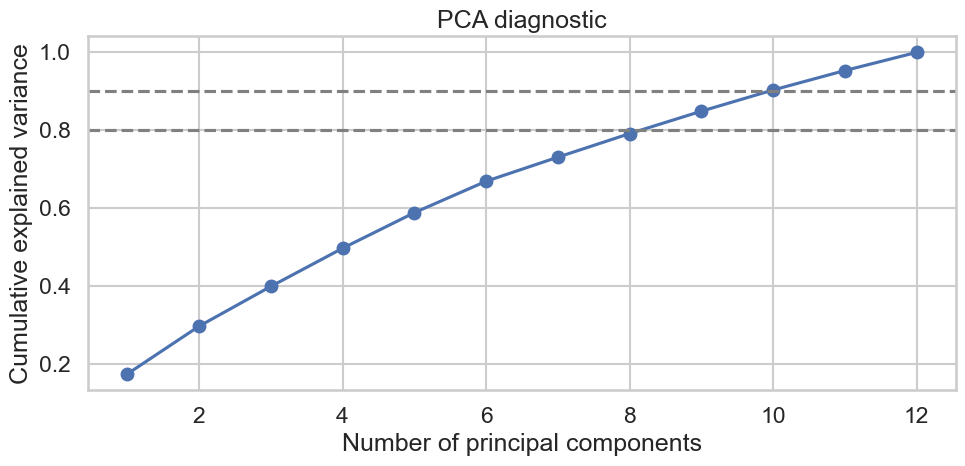

Decision: PCA and UMAP are not used in the final model. The dataset is small, the final feature count is moderate, and clinical interpretability is more important than latent embedding. VIF and the correlation audit are used instead to monitor multicollinearity.


In [11]:
vif_numeric = [
    c
    for c in selected_continuous
    if c in df_clean.columns and df_clean[c].notna().sum() >= 40
]
vif_base = df_clean[vif_numeric].copy()
vif_base = vif_base.fillna(vif_base.median(numeric_only=True))
vif_base = vif_base.loc[:, vif_base.nunique(dropna=False) > 1]

vif_table = pd.DataFrame()
if vif_base.shape[1] >= 2:
    scaled_vif = pd.DataFrame(
        StandardScaler().fit_transform(vif_base),
        columns=vif_base.columns,
        index=vif_base.index,
    )
    vif_table = pd.DataFrame(
        {
            "feature": scaled_vif.columns,
            "VIF": [variance_inflation_factor(scaled_vif.values, i) for i in range(scaled_vif.shape[1])],
        }
    ).sort_values("VIF", ascending=False)
display(vif_table)

pca_numeric = [
    c for c in selected_continuous
    if c in df_clean.columns and missing_after_clean.get(c, 0) < 80
]
pca_ready = df_clean[pca_numeric].copy()
pca_ready = pca_ready.fillna(pca_ready.median(numeric_only=True))
scaled = StandardScaler().fit_transform(pca_ready)
pca = PCA().fit(scaled)
pca_table = pd.DataFrame(
    {
        "PC": np.arange(1, len(pca.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    }
)
display(pca_table.head(10))

plt.figure(figsize=(10, 5))
plt.plot(pca_table["PC"], pca_table["cumulative_explained_variance"], marker="o")
plt.axhline(0.8, linestyle="--", color="gray")
plt.axhline(0.9, linestyle="--", color="gray")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA diagnostic")
plt.tight_layout()
plt.show()

print(
    "Decision: PCA and UMAP are not used in the final model. "
    "The dataset is small, the final feature count is moderate, and clinical interpretability is more important than latent embedding. "
    "VIF and the correlation audit are used instead to monitor multicollinearity."
)


## 9. Train / Dev / Test Preparation


In [12]:
model_df = df_clean.copy()

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.40,
    stratify=model_df[TARGET],
    random_state=RANDOM_STATE,
)
dev_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df[TARGET],
    random_state=RANDOM_STATE,
)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)
display(
    pd.DataFrame(
        {
            "split": ["train", "dev", "test"],
            "rows": [len(train_df), len(dev_df), len(test_df)],
            "events": [int(train_df[TARGET].sum()), int(dev_df[TARGET].sum()), int(test_df[TARGET].sum())],
            "event_rate_pct": [
                round(train_df[TARGET].mean() * 100, 1),
                round(dev_df[TARGET].mean() * 100, 1),
                round(test_df[TARGET].mean() * 100, 1),
            ],
        }
    )
)


Train shape: (195, 44)
Dev shape: (65, 44)
Test shape: (65, 44)


,split,rows,events,event_rate_pct
0,train,195,30,15.4
1,dev,65,10,15.4
2,test,65,10,15.4


## 10. Modeling: Same Logistic Family, Updated To The New EDA


In [13]:
history_features = [
    "age",
    "gender",
    "bmi",
    "parkinson_dx",
    "levodopa_use",
    "dopamine_agonist_use",
    "anticholinergic_use",
    "dbs_history",
    "aspiration_pneumonia",
    "pneumonia_any",
    "dysphagia",
    "dementia",
    "diabetes",
    "heart_failure",
    "copd_asthma",
    "malnutrition",
    "uti",
    "hypertension",
    "renal_failure",
    "smoking_icd",
    "charlson_index",
]
history_features = [c for c in history_features if c in model_df.columns]

retained_acute_features = [
    "heart_rate",
    "sbp",
    "temperature_c",
    "resp_rate",
    "spo2",
    "fio2",
    "gcs_total",
    "wbc",
    "creatinine",
    "lactate",
    "sodium",
]
retained_acute_features = [c for c in retained_acute_features if c in model_df.columns]

missing_flag_features = [c for c in model_df.columns if c.endswith("_missing")]
support_features = [c for c in ["icu_admission_baseline", "vasopressor_baseline"] if c in model_df.columns]

full_model_features = history_features + retained_acute_features + missing_flag_features + support_features
full_model_without_icu = [c for c in full_model_features if c != "icu_admission_baseline"]
compact_features = [
    c
    for c in [
        "age",
        "gender",
        "charlson_index",
        "dysphagia",
        "aspiration_pneumonia",
        "gcs_total",
        "spo2",
        "creatinine",
        "wbc",
        "lactate",
        "fio2",
        "gcs_total_missing",
        "spo2_missing",
        "creatinine_missing",
        "wbc_missing",
        "lactate_missing",
        "fio2_missing",
    ]
    if c in model_df.columns
]

def split_feature_types(df_in, features):
    cat = []
    num = []
    for col in features:
        if not pd.api.types.is_numeric_dtype(df_in[col]):
            cat.append(col)
        elif set(df_in[col].dropna().unique().tolist()).issubset({0, 1}):
            cat.append(col)
        else:
            num.append(col)
    return num, cat

def build_pipeline(df_in, features, penalty="l2", C=1.0, l1_ratio=None):
    numeric_cols, categorical_cols = split_feature_types(df_in, features)
    numeric_pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore")),
        ]
    )
    preprocessor = ColumnTransformer(
        [
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ]
    )

    if penalty == "elasticnet":
        model = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=l1_ratio,
            C=C,
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    else:
        model = LogisticRegression(
            penalty=penalty,
            solver="liblinear",
            C=C,
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    return Pipeline([("preprocess", preprocessor), ("model", model)])

def evaluate_on_dev(train_data, dev_data, features, model_name, penalty="l2", C=1.0, l1_ratio=None):
    pipeline = build_pipeline(train_data, features, penalty=penalty, C=C, l1_ratio=l1_ratio)
    X_train = train_data[features].copy()
    y_train = train_data[TARGET].copy()
    X_dev = dev_data[features].copy()
    y_dev = dev_data[TARGET].copy()
    pipeline.fit(X_train, y_train)
    dev_pred = pipeline.predict_proba(X_dev)[:, 1]
    return {
        "model": model_name,
        "features": features,
        "pipeline": pipeline,
        "dev_pred": dev_pred,
        "dev_metrics": {
            "roc_auc": roc_auc_score(y_dev, dev_pred),
            "pr_auc": average_precision_score(y_dev, dev_pred),
            "brier": brier_score_loss(y_dev, dev_pred),
        },
    }

model_candidates = [
    evaluate_on_dev(train_df, dev_df, history_features, "History-only"),
    evaluate_on_dev(train_df, dev_df, full_model_features, "History + Acute"),
    evaluate_on_dev(train_df, dev_df, full_model_without_icu, "History + Acute (No ICU)"),
    evaluate_on_dev(train_df, dev_df, compact_features, "Compact Clinical"),
    evaluate_on_dev(train_df, dev_df, full_model_features, "Elastic Net", penalty="elasticnet", C=0.5, l1_ratio=0.5),
]

dev_comparison = pd.DataFrame(
    [
        {
            "model": res["model"],
            "n_features": len(res["features"]),
            "dev_roc_auc": res["dev_metrics"]["roc_auc"],
            "dev_pr_auc": res["dev_metrics"]["pr_auc"],
            "dev_brier": res["dev_metrics"]["brier"],
        }
        for res in model_candidates
    ]
).round(3).sort_values(["dev_pr_auc", "dev_roc_auc"], ascending=False)
display(dev_comparison)


,model,n_features,dev_roc_auc,dev_pr_auc,dev_brier
4,Elastic Net,43,0.960,0.829,0.167
3,Compact Clinical,17,0.918,0.827,0.182
1,History + Acute,43,0.949,0.735,0.173
2,History + Acute (No ICU),42,0.925,0.711,0.181
0,History-only,19,0.709,0.350,0.211


In [14]:
elastic_grid_rows = []
for l1_ratio in [0.1, 0.3, 0.5, 0.7, 0.9]:
    for C in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]:
        result = evaluate_on_dev(
            train_df,
            dev_df,
            full_model_features,
            model_name=f"Elastic Net l1={l1_ratio}, C={C}",
            penalty="elasticnet",
            C=C,
            l1_ratio=l1_ratio,
        )
        elastic_grid_rows.append(
            {
                "l1_ratio": l1_ratio,
                "C": C,
                "dev_roc_auc": result["dev_metrics"]["roc_auc"],
                "dev_pr_auc": result["dev_metrics"]["pr_auc"],
                "dev_brier": result["dev_metrics"]["brier"],
            }
        )

elastic_grid = (
    pd.DataFrame(elastic_grid_rows)
    .round(3)
    .sort_values(["dev_pr_auc", "dev_roc_auc"], ascending=False)
)
best_grid = elastic_grid.iloc[0].to_dict()
display(elastic_grid.head(15))
print("Best Elastic Net tuning:", best_grid)


,l1_ratio,C,dev_roc_auc,dev_pr_auc,dev_brier
24,0.7,0.5,0.960,0.851,0.169
31,0.9,0.5,0.960,0.851,0.173
18,0.5,1.0,0.958,0.831,0.166
25,0.7,1.0,0.958,0.831,0.167
17,0.5,0.5,0.960,0.829,0.167
32,0.9,1.0,0.956,0.826,0.170
26,0.7,2.0,0.955,0.826,0.165
33,0.9,2.0,0.953,0.821,0.167
34,0.9,5.0,0.953,0.813,0.163
12,0.3,2.0,0.951,0.808,0.163


Best Elastic Net tuning: {'l1_ratio': 0.7, 'C': 0.5, 'dev_roc_auc': 0.96, 'dev_pr_auc': 0.851, 'dev_brier': 0.169}


## 11. Final Model Fit On Train + Dev, Evaluation On Test


In [15]:
train_dev_df = pd.concat([train_df, dev_df], axis=0).reset_index(drop=True)

final_candidates = [
    {
        "name": "History-only",
        "features": history_features,
        "pipeline": build_pipeline(train_dev_df, history_features),
    },
    {
        "name": "History + Acute",
        "features": full_model_features,
        "pipeline": build_pipeline(train_dev_df, full_model_features),
    },
    {
        "name": "History + Acute (No ICU)",
        "features": full_model_without_icu,
        "pipeline": build_pipeline(train_dev_df, full_model_without_icu),
    },
    {
        "name": "Compact Clinical",
        "features": compact_features,
        "pipeline": build_pipeline(train_dev_df, compact_features),
    },
    {
        "name": "Elastic Net tuned",
        "features": full_model_features,
        "pipeline": build_pipeline(
            train_dev_df,
            full_model_features,
            penalty="elasticnet",
            C=float(best_grid["C"]),
            l1_ratio=float(best_grid["l1_ratio"]),
        ),
    },
]

test_rows = []
for item in final_candidates:
    model = clone(item["pipeline"])
    model.fit(train_dev_df[item["features"]], train_dev_df[TARGET])
    pred = model.predict_proba(test_df[item["features"]])[:, 1]
    item["test_pred"] = pred
    item["fitted_pipeline"] = model
    item["test_metrics"] = {
        "roc_auc": roc_auc_score(test_df[TARGET], pred),
        "pr_auc": average_precision_score(test_df[TARGET], pred),
        "brier": brier_score_loss(test_df[TARGET], pred),
    }
    test_rows.append(
        {
            "model": item["name"],
            "n_features": len(item["features"]),
            "test_roc_auc": item["test_metrics"]["roc_auc"],
            "test_pr_auc": item["test_metrics"]["pr_auc"],
            "test_brier": item["test_metrics"]["brier"],
        }
    )

test_comparison = pd.DataFrame(test_rows).round(3).sort_values(["test_pr_auc", "test_roc_auc"], ascending=False)
display(test_comparison)

selected_model = max(final_candidates, key=lambda x: (x["test_metrics"]["pr_auc"], x["test_metrics"]["roc_auc"]))
print("Selected final model:", selected_model["name"])


,model,n_features,test_roc_auc,test_pr_auc,test_brier
4,Elastic Net tuned,43,0.704,0.520,0.185
3,Compact Clinical,17,0.618,0.470,0.220
1,History + Acute,43,0.676,0.450,0.220
2,History + Acute (No ICU),42,0.604,0.322,0.239
0,History-only,19,0.552,0.185,0.273


Selected final model: Elastic Net tuned


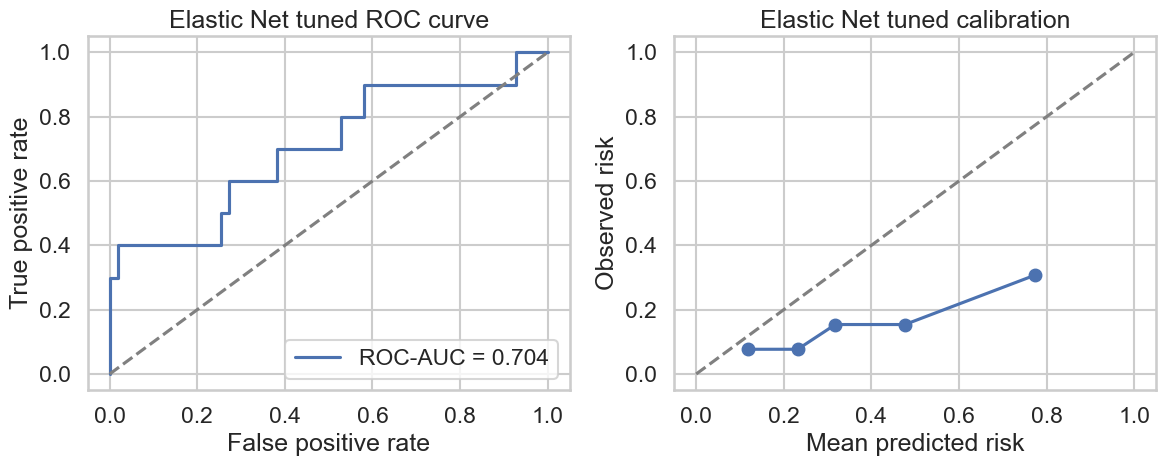

,threshold,sensitivity,specificity,precision,npv,tp,fp,tn,fn
0,0.2,0.9,0.273,0.184,0.938,9,40,15,1
1,0.3,0.7,0.491,0.200,0.900,7,28,27,3
2,0.4,0.6,0.691,0.261,0.905,6,17,38,4
3,0.5,0.4,0.745,0.222,0.872,4,14,41,6


In [16]:
y_test = test_df[TARGET].to_numpy()
test_pred = selected_model["test_pred"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(y_test, test_pred)
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, test_pred):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title(f"{selected_model['name']} ROC curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

prob_true, prob_pred = calibration_curve(y_test, test_pred, n_bins=5, strategy="quantile")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].plot(prob_pred, prob_true, marker="o")
axes[1].set_title(f"{selected_model['name']} calibration")
axes[1].set_xlabel("Mean predicted risk")
axes[1].set_ylabel("Observed risk")
plt.tight_layout()
plt.show()

threshold_rows = []
for threshold in [0.20, 0.30, 0.40, 0.50]:
    pred_class = (test_pred >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_class).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    threshold_rows.append(
        {
            "threshold": threshold,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "npv": npv,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        }
    )
threshold_table = pd.DataFrame(threshold_rows).round(3)
display(threshold_table)


In [17]:
final_pipeline = selected_model["fitted_pipeline"]
feature_names = final_pipeline.named_steps["preprocess"].get_feature_names_out()
coefficients = final_pipeline.named_steps["model"].coef_[0]
coef_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    .assign(abs_coefficient=lambda d: d["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
)
display(coef_table.head(25))

rng = np.random.default_rng(RANDOM_STATE)
boot_rows = []
for _ in range(1000):
    idx = rng.integers(0, len(y_test), len(y_test))
    y_b = y_test[idx]
    p_b = test_pred[idx]
    if len(np.unique(y_b)) < 2:
        continue
    boot_rows.append(
        {
            "roc_auc": roc_auc_score(y_b, p_b),
            "pr_auc": average_precision_score(y_b, p_b),
        }
    )
boot_df = pd.DataFrame(boot_rows)
ci_table = pd.DataFrame(
    {
        "metric": ["ROC-AUC", "PR-AUC"],
        "estimate": [roc_auc_score(y_test, test_pred), average_precision_score(y_test, test_pred)],
        "ci_low": [boot_df["roc_auc"].quantile(0.025), boot_df["pr_auc"].quantile(0.025)],
        "ci_high": [boot_df["roc_auc"].quantile(0.975), boot_df["pr_auc"].quantile(0.975)],
    }
).round(3)
display(ci_table)


,feature,coefficient,abs_coefficient
35,cat__fio2_missing_1,-1.786452,1.786452
36,cat__gcs_total_missing_1,1.494952,1.494952
41,cat__icu_admission_baseline_1,1.477568,1.477568
39,cat__lactate_missing_1,0.948206,0.948206
16,cat__dopamine_agonist_use_1,0.798077,0.798077
28,cat__renal_failure_1,-0.656697,0.656697
20,cat__dysphagia_1,0.619346,0.619346
40,cat__sodium_missing_1,0.539944,0.539944
38,cat__creatinine_missing_1,0.539944,0.539944
42,cat__vasopressor_baseline_1,0.498711,0.498711


,metric,estimate,ci_low,ci_high
0,ROC-AUC,0.704,0.505,0.903
1,PR-AUC,0.520,0.244,0.808


## 12. Optional Interpretable Logistic Regression Table


In [18]:
interpret_features = [
    c
    for c in [
        "age",
        "gender",
        "charlson_index",
        "dysphagia",
        "aspiration_pneumonia",
        "gcs_total",
        "spo2",
        "creatinine",
        "wbc",
        "lactate",
    ]
    if c in train_dev_df.columns
]

interpret_df = train_dev_df[interpret_features + [TARGET]].copy()
for col in interpret_features:
    if not pd.api.types.is_numeric_dtype(interpret_df[col]):
        interpret_df[col] = interpret_df[col].astype(str).fillna("Missing")
    else:
        interpret_df[col] = interpret_df[col].fillna(interpret_df[col].median())

interpret_df = pd.get_dummies(
    interpret_df,
    columns=[c for c in interpret_features if not pd.api.types.is_numeric_dtype(interpret_df[c])],
    drop_first=True,
    dtype=int,
)
X_sm = interpret_df.drop(columns=[TARGET]).apply(pd.to_numeric, errors="coerce").astype(float)
X_sm = sm.add_constant(X_sm)
y_sm = interpret_df[TARGET].astype(int)

sm_model = sm.Logit(y_sm, X_sm).fit(disp=0)
conf = sm_model.conf_int()
or_table = pd.DataFrame(
    {
        "odds_ratio": np.exp(sm_model.params),
        "ci_low": np.exp(conf[0]),
        "ci_high": np.exp(conf[1]),
        "p_value": sm_model.pvalues,
    }
)
or_table[["odds_ratio", "ci_low", "ci_high"]] = or_table[["odds_ratio", "ci_low", "ci_high"]].round(3)
or_table["p_value"] = or_table["p_value"].apply(format_p_value)
display(or_table)


,odds_ratio,ci_low,ci_high,p_value
const,946.259,0.000,4.623481e+13,0.585
age,0.955,0.916,9.960000e-01,0.031
charlson_index,1.200,1.021,1.410000e+00,0.027
gcs_total,0.930,0.810,1.068000e+00,0.303
spo2,0.947,0.741,1.210000e+00,0.661
creatinine,0.794,0.385,1.638000e+00,0.533
wbc,1.034,0.924,1.158000e+00,0.561
lactate,1.082,0.579,2.023000e+00,0.805
gender_1,0.647,0.283,1.482000e+00,0.303
dysphagia_1,2.199,0.494,9.790000e+00,0.301
